   Scrivere il problema di Empirical Risk Minimization per una regressione lineare sui seguenti dati, utilizzando la Squared Error Loss
    "| OBJECT ID | FEAT 1 | FEAT 2 | LABEL |\n",
    "|-|-|-|-|\n",
    "| a | 0 | 10 | 2 |\n",
    "| b | -1 | 9 | 0.5 |\n",
    "| c | 0 | 0 | 0 |\n",
    "| d | 98 | 99 | 100 |"

In [2]:
!pip install scikit-learn matplotlib numpy pandas plotly

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl (12.4 MB)
Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl (9.9 MB)
   ---------------------------------------- 0

In [3]:
!pip install --upgrade nbformat


   ----------------- ---------------------- 3/7 [referencing]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------------------- 7/7 [nbformat]



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression


In [5]:
# creazione di matrice per le features
x = np.array([[0, 10], [-1, 9], [0, 0], [98, 99]])
# creazione di vettore per le label
y = np.array([2, 0.5, 0, 100])

In [6]:
# creazione del modello di regressione lineare
model = LinearRegression()
model.fit(x, y)
w_model = model.coef_
print("Coefficiente di regressione:", w_model)

Coefficiente di regressione: [0.84251683 0.17614156]


In [7]:
w_analytical = np.linalg.inv(x.T @ x) @ x.T @ y
print("Coefficiente di regressione (analitico):", w_analytical)

Coefficiente di regressione (analitico): [0.84271848 0.17591963]


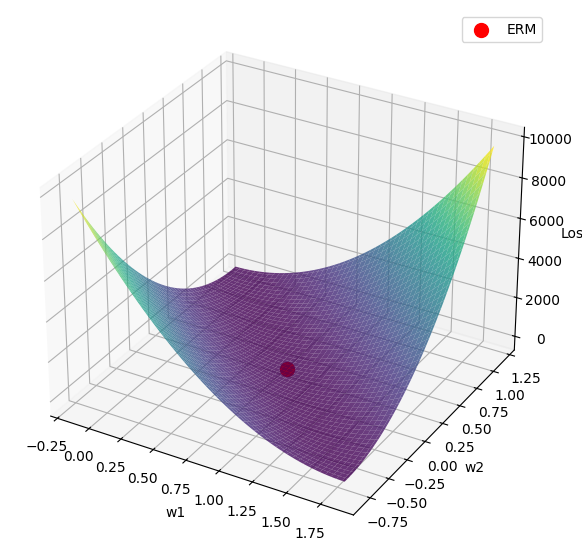

In [8]:
w1_vals = np.linspace(w_model[0] - 1, w_model[0] + 1, 100)
w2_vals = np.linspace(w_model[1] - 1, w_model[1] + 1, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)

loss = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w = np.array([W1[i, j], W2[i, j]])
        y_pred = x @ w
        loss[i, j] = np.mean((y - y_pred) ** 2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, loss, cmap='viridis', alpha=0.8)
ax.scatter(w_model[0], w_model[1], np.mean((y - x @ w_model) ** 2), color='red', s=100, label='ERM')
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('Loss')
ax.legend()
plt.show()

In [9]:
# creazione del grafico interattivo con Plotly
fig = go.Figure(data=[go.Surface(z=loss, x=W1, y=W2, colorscale='Viridis', opacity=0.8)])
fig.add_trace(go.Scatter3d(x=[w_model[0]], y=[w_model[1]], z=[np.mean((y - x @ w_model) ** 2)], mode='markers', marker=dict(size=10, color='red'), name='ERM'))
fig.update_layout(title='Loss Surface', scene=dict(xaxis_title='w1', yaxis_title='w2', zaxis_title='Loss'))
fig.show()